# Online Retail EDA

This notebook performs first-pass exploratory data analysis for the Online Retail dataset.


In [1]:
from pathlib import Path
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid', context='talk')


In [2]:
DATA_DIR = Path('../data/raw')
candidate_files = list(DATA_DIR.glob('*.xlsx')) + list(DATA_DIR.glob('*.xls')) + list(DATA_DIR.glob('*.csv'))
if not candidate_files:
    raise FileNotFoundError('No raw dataset found in ../data/raw/. Add the Online Retail file first.')
data_path = candidate_files[0]
if data_path.suffix.lower() in ['.xlsx', '.xls']:
    df = pd.read_excel(data_path)
else:
    df = pd.read_csv(data_path, encoding='ISO-8859-1')
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
print('Shape:', df.shape)
print(df.dtypes)
null_summary = pd.DataFrame({'missing_count': df.isna().sum(), 'missing_pct': (df.isna().mean()*100).round(2)})
null_summary.sort_values('missing_pct', ascending=False)


Shape: (541909, 8)
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object


,missing_count,missing_pct
CustomerID,135080,24.93
Description,1454,0.27
StockCode,0,0.00
InvoiceNo,0,0.00
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
Country,0,0.00


In [4]:
eda = df.copy()
eda['InvoiceNo'] = eda['InvoiceNo'].astype(str)
eda['InvoiceDate'] = pd.to_datetime(eda['InvoiceDate'], errors='coerce')
eda['CustomerID'] = eda['CustomerID'].astype('string')
eda['LineRevenue'] = eda['Quantity'] * eda['UnitPrice']
eda['IsCancelled'] = eda['InvoiceNo'].str.startswith('C', na=False)
pd.Series({
    'rows': len(eda),
    'unique_customers': eda['CustomerID'].nunique(dropna=True),
    'unique_invoices': eda['InvoiceNo'].nunique(),
    'cancelled_rows': int(eda['IsCancelled'].sum())
})


rows                541909
unique_customers      4372
unique_invoices      25900
cancelled_rows        9288
dtype: int64

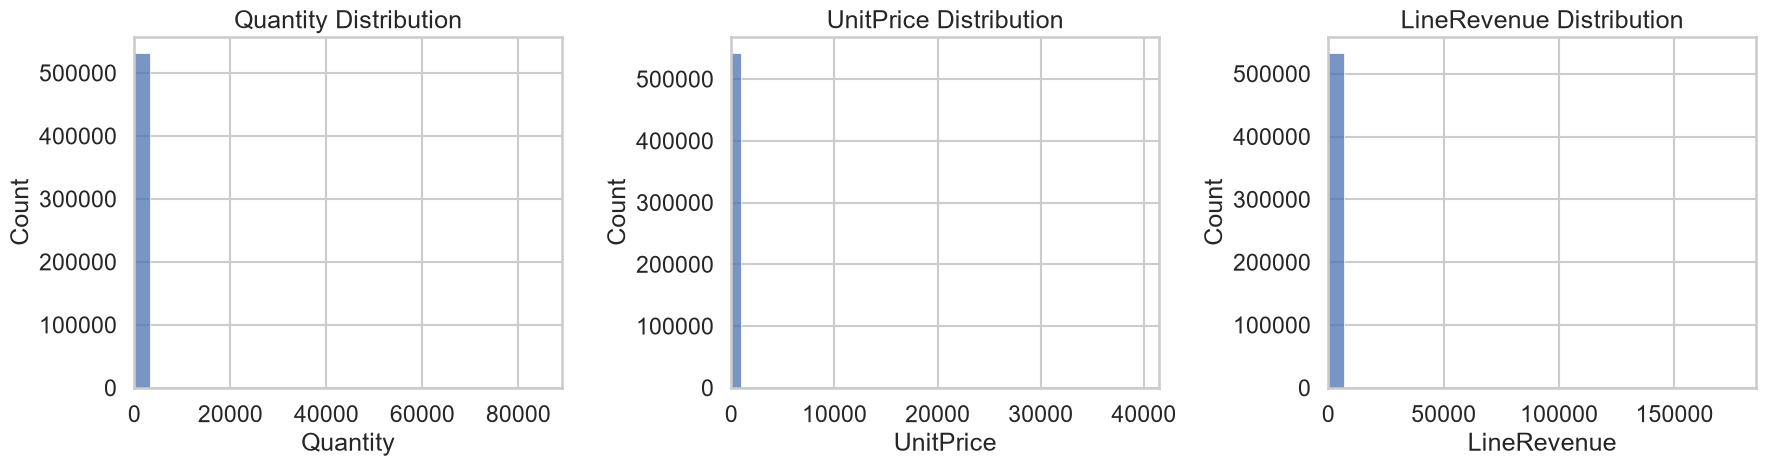

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(eda['Quantity'], bins=50, ax=axes[0])
axes[0].set_title('Quantity Distribution')
sns.histplot(eda['UnitPrice'], bins=50, ax=axes[1])
axes[1].set_title('UnitPrice Distribution')
sns.histplot(eda['LineRevenue'], bins=50, ax=axes[2])
axes[2].set_title('LineRevenue Distribution')
for ax in axes:
    ax.set_xlim(left=0)
plt.tight_layout()


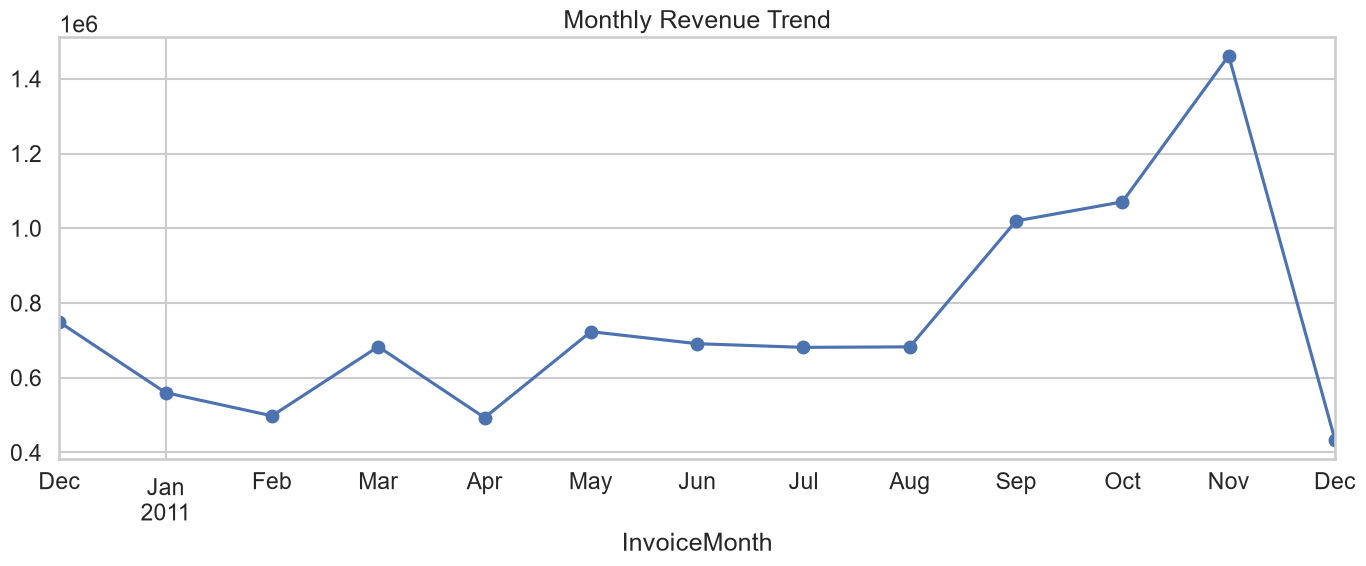

In [6]:
monthly_revenue = (eda.dropna(subset=['InvoiceDate'])
    .assign(InvoiceMonth=lambda x: x['InvoiceDate'].dt.to_period('M').dt.to_timestamp())
    .groupby('InvoiceMonth')['LineRevenue'].sum().sort_index())
plt.figure(figsize=(14, 6))
monthly_revenue.plot(marker='o')
plt.title('Monthly Revenue Trend')
plt.tight_layout()


## Next

Use the preprocessing notebook to create a cleaned dataset for modeling.
